# Visual analysis of images  (2014)

In [1]:
import random

import pandas as pd
import numpy as np
from tqdm import tqdm
import json

## 1. Read embedding file

In [2]:
df = pd.read_csv('../../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors.image', sep='\t')
df.head(5)

,img_id:token,img_emb:float_seq
0,0,0.014428207 -0.01609465 0.03294648 0.010992038...
1,1,0.013374746 -0.0040851366 0.017846484 0.009146...
2,3,0.025485406 0.044892143 0.06540884 0.07273897 ...
3,2,0.0927549 0.0003234906 0.0068842433 0.05643998...
4,4,0.026845569 -0.0059881625 0.06385405 -0.019091...


## 2. Preprocess embeddings

In [3]:
df.rename(columns={"img_emb:float_seq": "emb", "img_id:token": "id"}, inplace=True)
df["emb"] = df["emb"].apply(lambda x: np.fromstring(x, dtype=np.float32, sep=' '))
df.head(5)

,id,emb
0,0,"[0.014428207, -0.01609465, 0.03294648, 0.01099..."
1,1,"[0.013374746, -0.0040851366, 0.017846484, 0.00..."
2,3,"[0.025485406, 0.044892143, 0.06540884, 0.07273..."
3,2,"[0.0927549, 0.0003234906, 0.0068842433, 0.0564..."
4,4,"[0.026845569, -0.0059881625, 0.06385405, -0.01..."


## 3. Fit KNN with static embeddings

In [4]:
from sklearn.neighbors import NearestNeighbors

X = np.vstack(df["emb"].values)
knn = NearestNeighbors(n_neighbors=10, metric='cosine')
knn.fit(X)

,n_neighbors,10
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


## 4. Take random item and find its neighbours

In [60]:
import random

n_ids = df["id"].shape[0]

while True:
    random_idx = random.choice(range(n_ids))

    if sum(X[random_idx]) != 0:
        break

orig_id = df["id"].iloc[random_idx]

dist, nearest_ids = knn.kneighbors([X[random_idx]])

print(orig_id)

11591


## 5. Convert into correct metadata

In [61]:
ids = nearest_ids[0]
distances = dist[0]

# Read the mappings
with open('../../../Amazon_Sports_and_Outdoors/item_mapping_Amazon_Sports_and_Outdoors.json', encoding='utf-8') as f:
    asin_mapping = json.load(f)

parent_asins = [asin_mapping[idx] for idx in ids]
print(parent_asins[:10])

['B00419HNW4', 'B00419HNBU', 'B0053C3PRU', 'B000WU9LCQ', 'B004PFJFBQ', 'B000ZKR65C', 'B003IXFDE4', 'B003RLLPOO', 'B000FJEZAC', 'B004YJ2V6O']


In [62]:
import ast

data = {}
orig_img_url = ''
with open('../../../Amazon_Sports_and_Outdoors/meta_Sports_and_Outdoors.json') as f:
    for line in f:
        entry = ast.literal_eval(line)

        image_url = entry.get('imUrl', None)
        parent_asin = entry['asin']

        if parent_asin == asin_mapping[orig_id]:
            orig_img_url = image_url
            continue

        if not image_url or parent_asin not in parent_asins:
            continue

        data[parent_asin] = image_url

## 6. Visual analysis

### 6.1 Original image

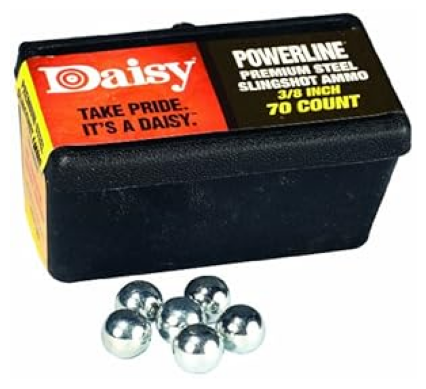

In [63]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

response = requests.get(orig_img_url, stream=True)
response.raise_for_status()

img = Image.open(BytesIO(response.content))
plt.imshow(img)
plt.axis('off')
plt.show()

### 6.2 Supposedly similar images (sorted by distance)

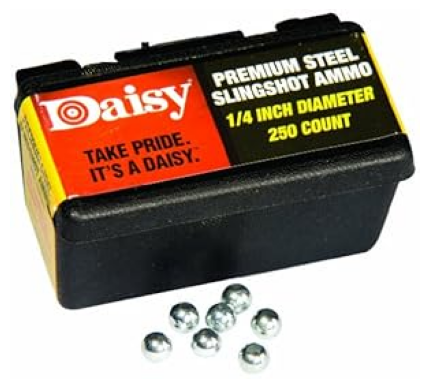

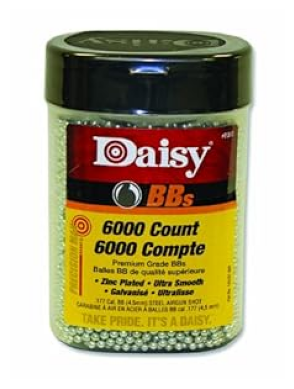

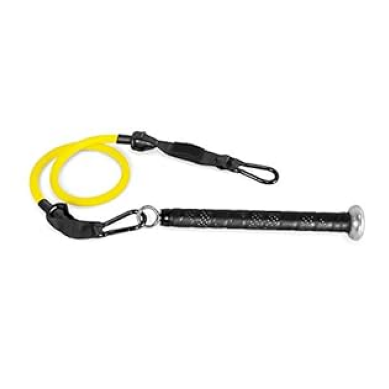

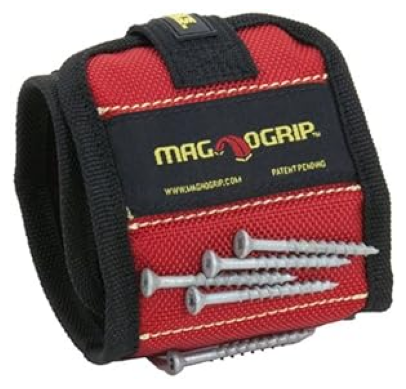

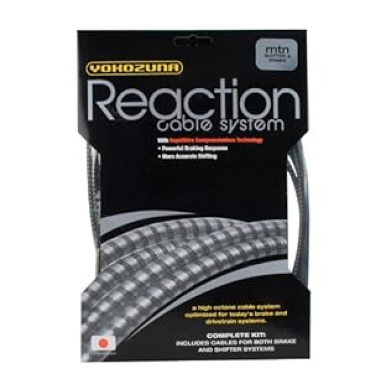

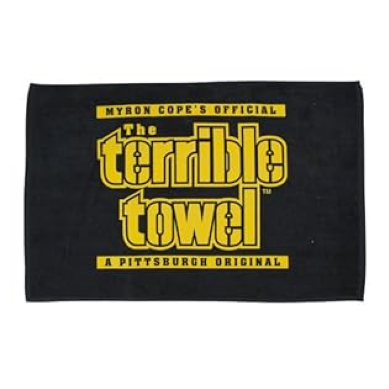

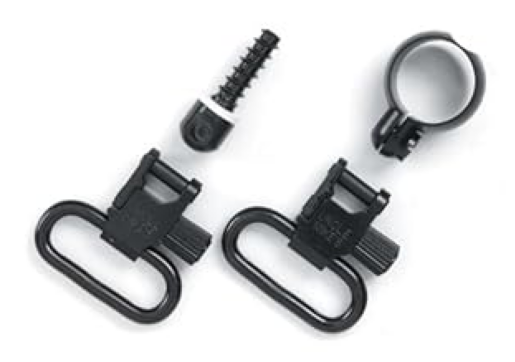

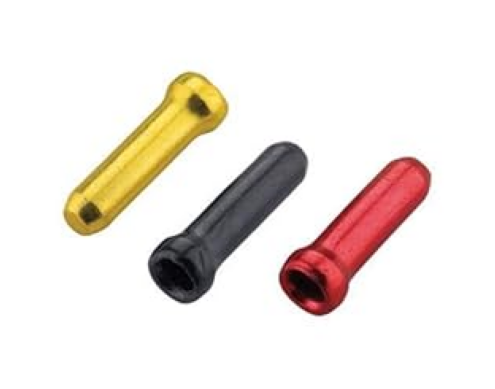

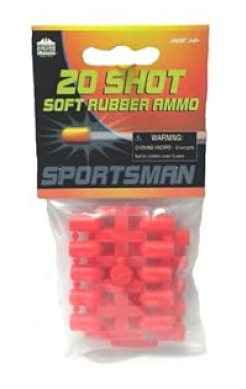

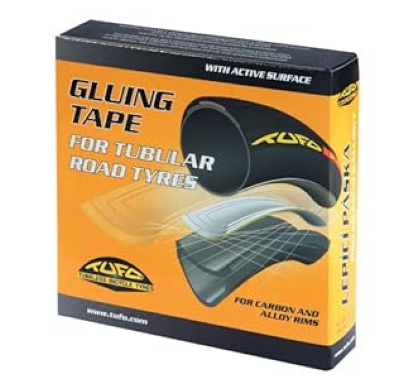

In [64]:
for parent_asin in parent_asins:
    url = data.get(parent_asin, None)
    if not url:
        continue

    response = requests.get(url, stream=True)
    response.raise_for_status()

    img = Image.open(BytesIO(response.content))
    plt.imshow(img)
    plt.axis('off')
    plt.show()